<a href="https://colab.research.google.com/github/enessbulut/YOLOv8/blob/main/image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/YOLOv8/3_image_segmentation

/content/drive/MyDrive/YOLOv8/3_image_segmentation


In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.7/112.6 GB disk)


In [ ]:
!unzip /content/drive/MyDrive/YOLOv8/3_image_segmentation/data/car_part_dataset.zip -d data

Archive:  /content/drive/MyDrive/YOLOv8/3_image_segmentation/data/car_part_dataset.zip
replace data/car_part_dataset/images/test/1003.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/car_part_dataset/images/test/1003.jpg  
  inflating: data/car_part_dataset/images/test/1008.jpg  
  inflating: data/car_part_dataset/images/test/1009.jpg  
  inflating: data/car_part_dataset/images/test/1012.jpg  
  inflating: data/car_part_dataset/images/test/1015.jpg  
  inflating: data/car_part_dataset/images/test/1022.jpg  
  inflating: data/car_part_dataset/images/test/1034.jpg  
  inflating: data/car_part_dataset/images/test/1036.jpg  
  inflating: data/car_part_dataset/images/test/1037.jpg  
  inflating: data/car_part_dataset/images/test/1049.jpg  
  inflating: data/car_part_dataset/images/test/105.jpg  
  inflating: data/car_part_dataset/images/test/1062.jpg  
  inflating: data/car_part_dataset/images/test/1066.jpg  
  inflating: data/car_part_dataset/images/test/1071.jpg  
  inflatin

In [ ]:
!yolo segment train data=/content/drive/MyDrive/YOLOv8/3_image_segmentation/data/config.yaml model=yolov8n-seg.pt epochs=20 imgsz=640 workers=8 batch=8 device=0

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLOv8/3_image_segmentation/data/config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [ ]:
!yolo segment predict model=/content/drive/MyDrive/YOLOv8/3_image_segmentation/runs/segment/train/weights/best.pt source='/content/drive/MyDrive/YOLOv8/3_image_segmentation/inference' save=True

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,259,819 parameters, 0 gradients, 11.4 GFLOPs

image 1/175 /content/drive/MyDrive/YOLOv8/3_image_segmentation/inference/100.jpg: 640x640 2 back_doors, 1 front_bumper, 1 front_door, 1 front_glass, 1 front_light, 1 hood, 7.5ms
image 2/175 /content/drive/MyDrive/YOLOv8/3_image_segmentation/inference/1002.jpg: 640x640 1 front_bumper, 1 front_glass, 2 front_lights, 1 hood, 40.0ms
image 3/175 /content/drive/MyDrive/YOLOv8/3_image_segmentation/inference/1019.jpg: 640x640 1 back_door, 1 back_glass, 1 back_light, 1 front_bumper, 1 front_door, 1 front_light, 17.4ms
image 4/175 /content/drive/MyDrive/YOLOv8/3_image_segmentation/inference/1032.jpg: 640x640 2 back_doors, 1 front_bumper, 1 front_door, 1 front_glass, 1 front_light, 1 hood, 20.4ms
image 5/175 /content/drive/MyDrive/YOLOv8/3_image_segmentation/inference/104.jpg: 640x640 1 back_door, 1 front_bumper, 1 front_door, 1


image 1/1 /content/drive/MyDrive/YOLOv8/3_image_segmentation/test.jpg: 480x640 1 back_door, 1 front_bumper, 1 front_door, 1 front_glass, 1 front_light, 1 hood, 8.9ms
Speed: 1.7ms preprocess, 8.9ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/drive/MyDrive/YOLOv8/3_image_segmentation/runs/segment/predict5


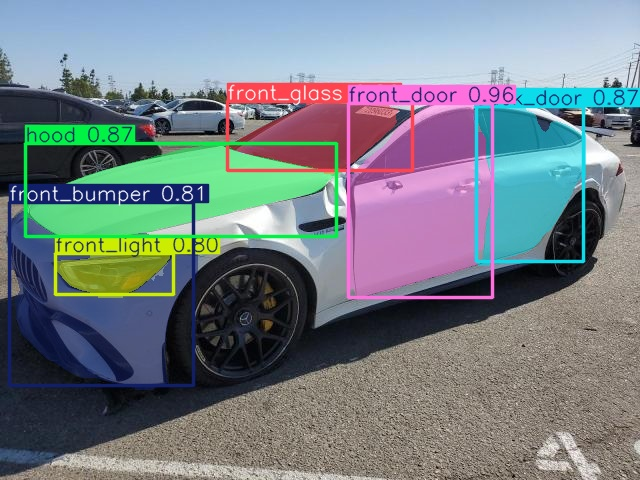

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO("/content/drive/MyDrive/YOLOv8/3_image_segmentation/runs/segment/train/weights/best.pt")


results = model.predict(
    source="/content/drive/MyDrive/YOLOv8/3_image_segmentation/test.jpg",
    imgsz=640,
    conf=0.25,
    save=True
)


img = cv2.imread(
    "/content/drive/MyDrive/YOLOv8/3_image_segmentation/runs/segment/predict2/test.jpg"
)


cv2_imshow(img)
